In [32]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [40]:
#1. import database/data
conn = sqlite3.connect('customer_churn.db')

sql_query ="""
          SELECT name
          FROM sqlite_master
          WHERE type='table';
"""

tables = pd.read_sql(sql_query,conn)

#create dataframe from table 
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] =df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [41]:
#Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables ['name'] : 
    print(f"\nTable Name: {table_name}")
    #Get Column Information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

#Closed connection
conn.close()



Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [35]:
# 2.Data Cleaning

In [42]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [43]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [38]:
# Modifications :-
#a.Rename Column :- Name
#b.Drop Coumns :- interest and pincode 
#c.change data type :- dob
#d.data standardization -gender
#e.Fix Missing Values :- country


In [44]:
#a.Rename Column :- Name
df_db_customer.rename(columns ={'name' : 'customer_name'}, inplace =True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [45]:
#b.Drop Coumns :- interest and pincode
df_db_customer.drop(df_db_customer.columns[-2:], axis=1, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [46]:
#c.change data type :- dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [47]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [51]:
#d. Data standardization _gender
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [52]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [58]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [60]:
df_db_customer.isna()

,customerid,customer_name,country,state,gender,dob
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


In [61]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [63]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [67]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [70]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [72]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [76]:
df_db_support.tail()


,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [77]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [79]:
df_db_support.drop(columns=['col_1','comment'], inplace =True)

In [83]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [84]:
#Feature Engineering and Data Analysis 

In [86]:
#Created a new Column using an existing column - CHURN flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [87]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [88]:
#First Fix Duplicates then merge

(df_db_subscription
 .merge(df_db_customer, on = 'customerid', how='left')
 .merge(df_db_support, on = 'customerid' , how ='left'))

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


(9, 4)

In [91]:
df_db_subscription['customerid'].nunique()

21

In [92]:
df_db_customer['customerid'].nunique()

21

In [93]:
df_db_support['customerid'].nunique()

7

In [94]:
df_db_support['customerid'].size

9

In [95]:
df.shape

(9, 4)

In [96]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [97]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [99]:
df_db_support= df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [100]:
df_db_support['customerid'].size

7

In [101]:
#merge df
df = (df_db_subscription
 .merge(df_db_customer, on = 'customerid', how='left')
 .merge(df_db_support, on = 'customerid' , how ='left'))

In [104]:
df.shape

(21, 21)

In [105]:
df.to_csv('exported_churn_data.csv', index=False)

In [103]:
# Data Analysis 

In [106]:
#1. Churn Rate

In [107]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [108]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [114]:
#2. Retention Rate
retention_rate =100-churn_rate
print("Retention Rate = ", round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [115]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [117]:
#3. Churn by Plan type
df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [119]:
churn_by_plan =(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [122]:
#4 a.Churn by state + sum(revenue) & count of users

churn_by_state = (df.groupby('state').agg(
    churn_rate_pct=('churn_flag','mean'),
    total_monthly_charges=('monthly_charges','sum'),
    user_count=('customerid','nunique')).reset_index())

churn_by_state['churn_rate_pct'] = (
    churn_by_state['churn_rate_pct'].mul(100).round(2)
)

churn_by_state['total_monthly_charges'] = (
    churn_by_state['total_monthly_charges'].round(2)
)

print(churn_by_state)


           state  churn_rate_pct  total_monthly_charges  user_count
0          Delhi           25.00                  52.96           4
1      Karnataka          100.00                  20.98           2
2      Kathmandu            0.00                  20.98           2
3    Maharashtra            0.00                  50.97           3
4      Meghalaya           66.67                  42.97           3
5       Nagaland            0.00                  22.99           1
6      Rajasthan            0.00                  36.98           2
7      Telangana           50.00                  30.98           2
8  Uttar Pradesh            0.00                 115.98           2


In [123]:
#4 b.Churn by Subscription Type
churn_by_subscription = (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', 'mean'),
          total_monthly_charges=('monthly_charges', 'sum'),
          user_count=('customerid', 'nunique')
      )
      .reset_index()
)

churn_by_subscription['churn_rate_pct'] = (
    churn_by_subscription['churn_rate_pct'].mul(100).round(2)
)

churn_by_subscription['total_monthly_charges'] = (
    churn_by_subscription['total_monthly_charges'].round(2)
)

print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_monthly_charges  user_count
0           Organic            0.00                 145.91           9
1              Paid           16.67                 174.94           6
2          Refferal           83.33                  74.94           6


In [124]:
#Average Revenue per User(ARPU)

In [126]:
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [133]:
#Average Customer Tenure
#count of days users has used our service : cancellation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today -df['subscription_start_date']).dt.days
)

df.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,2028.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1413.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2703.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [135]:
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1552 0


In [139]:
#Revenure at risk(Revenue loss from churned users
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print ("Average Revenue loss because of leaving Customers = " ,revenue_at_risk)


Average Revenue loss because of leaving Customers =  73.94


In [142]:
#8. Escalation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate = ", round(escalation_rate, 2), "%")

Escalation Rate =  19.05 %


In [143]:
#9. Average Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average complaints per user", round(avg_complaints,2))

Average complaints per user 0.43


In [145]:
#10. Correlation excalation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y',1,0)

,escalations,churn_flag
0,0,0
1,1,1
2,0,0
3,0,0
4,1,1
5,0,0
6,0,1
7,0,0
8,0,0
9,0,0


In [147]:
corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("correlaltion between escalation rate and churn rate is = " , round(correlation,2))

correlaltion between escalation rate and churn rate is =  0.77


In [148]:
# Creating an New Column using existing column 
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] <70),
    (df['churn_score'] >= 70),  
]

choices = ['Low','Med','High']
df['churn_risk'] = np.select(conditions,choices, default ='unknown')

In [149]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2028.0,Low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,High
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1413.0,Low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2703.0,Low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,High
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,...,India,Delhi,Female,1988-12-10,2025-03-18,0,90.0,1.0,1568.0,Low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,India,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,High
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,...,India,Rajasthan,Male,1999-03-14,NaT,0,NaN,NaN,2423.0,Low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,...,Nepal,Kathmandu,Female,1985-07-07,NaT,0,NaN,NaN,1169.0,Low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,None,6.99,335,...,Nepal,Kathmandu,Male,1993-10-29,NaT,0,NaN,NaN,1644.0,Low


In [150]:
#Visualisation using Matplotlib
df_visual = df.copy()
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [152]:
df_visual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn_flag               21 non-null     int64         
 12  customer_name            21 non-null  

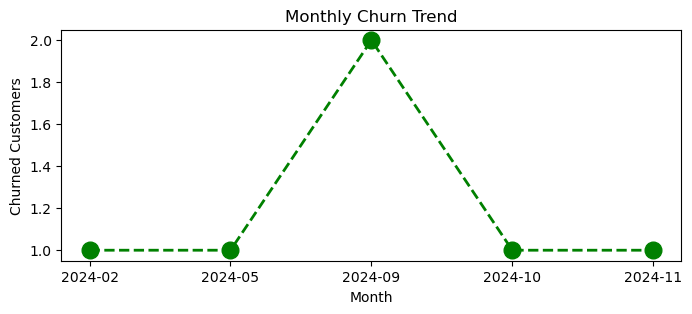

In [156]:
# 4.1 Monthly Churn Trend (Time Series KPI) 
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize =(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()


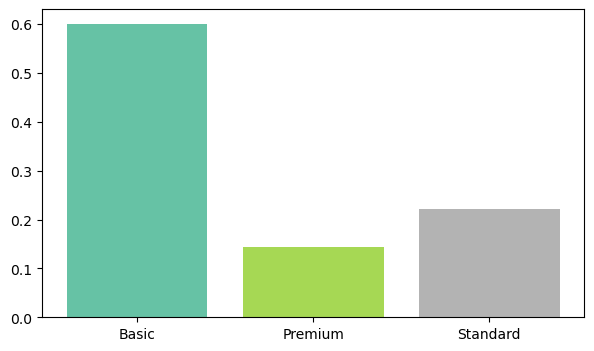

In [166]:
# 4.2 Churn By Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize =(7,4))
plt.bar(churn_plan.index, churn_plan.values,color=colors)
plt.show()

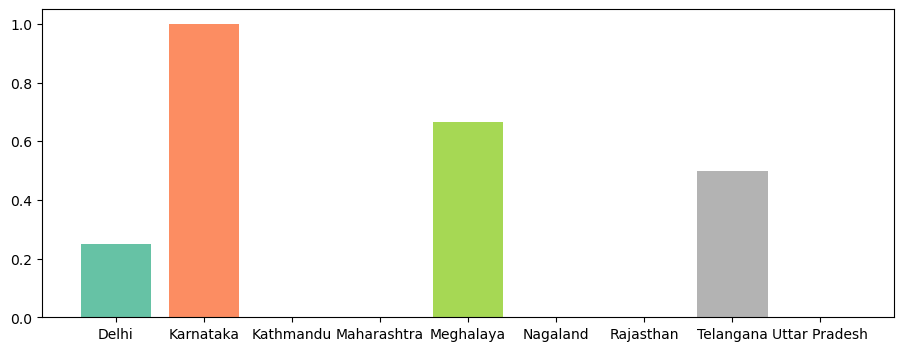

In [172]:
# 4.2 Churn By Sates
churn_state = df_visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1,len(churn_state)))
plt.figure(figsize =(11,4))
plt.bar(churn_state.index, churn_state.values,color=colors)
plt.show()

In [176]:
#Visualization using Seaborn
import warnings 
warnings.filterwarnings("ignore")

In [186]:
#Encoding- convert str to numeric as well as taking priority of values as well, so that we can find corr between features
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
order_mappings = {
     'plan_type': ['Basic','Standard','Premium'],
     'contract_type':['Monthly','Annual'],
     'churn_risk':['low','med','high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

<Axes: >

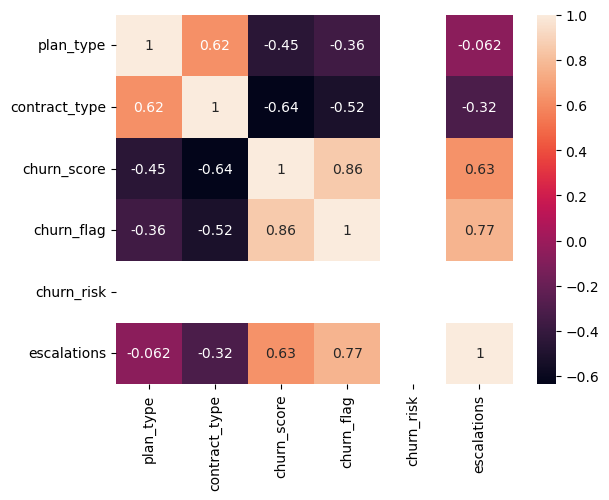

In [187]:
#Heatmap(correlation matrix)

sns.heatmap(df_encoded.corr(), annot = True)


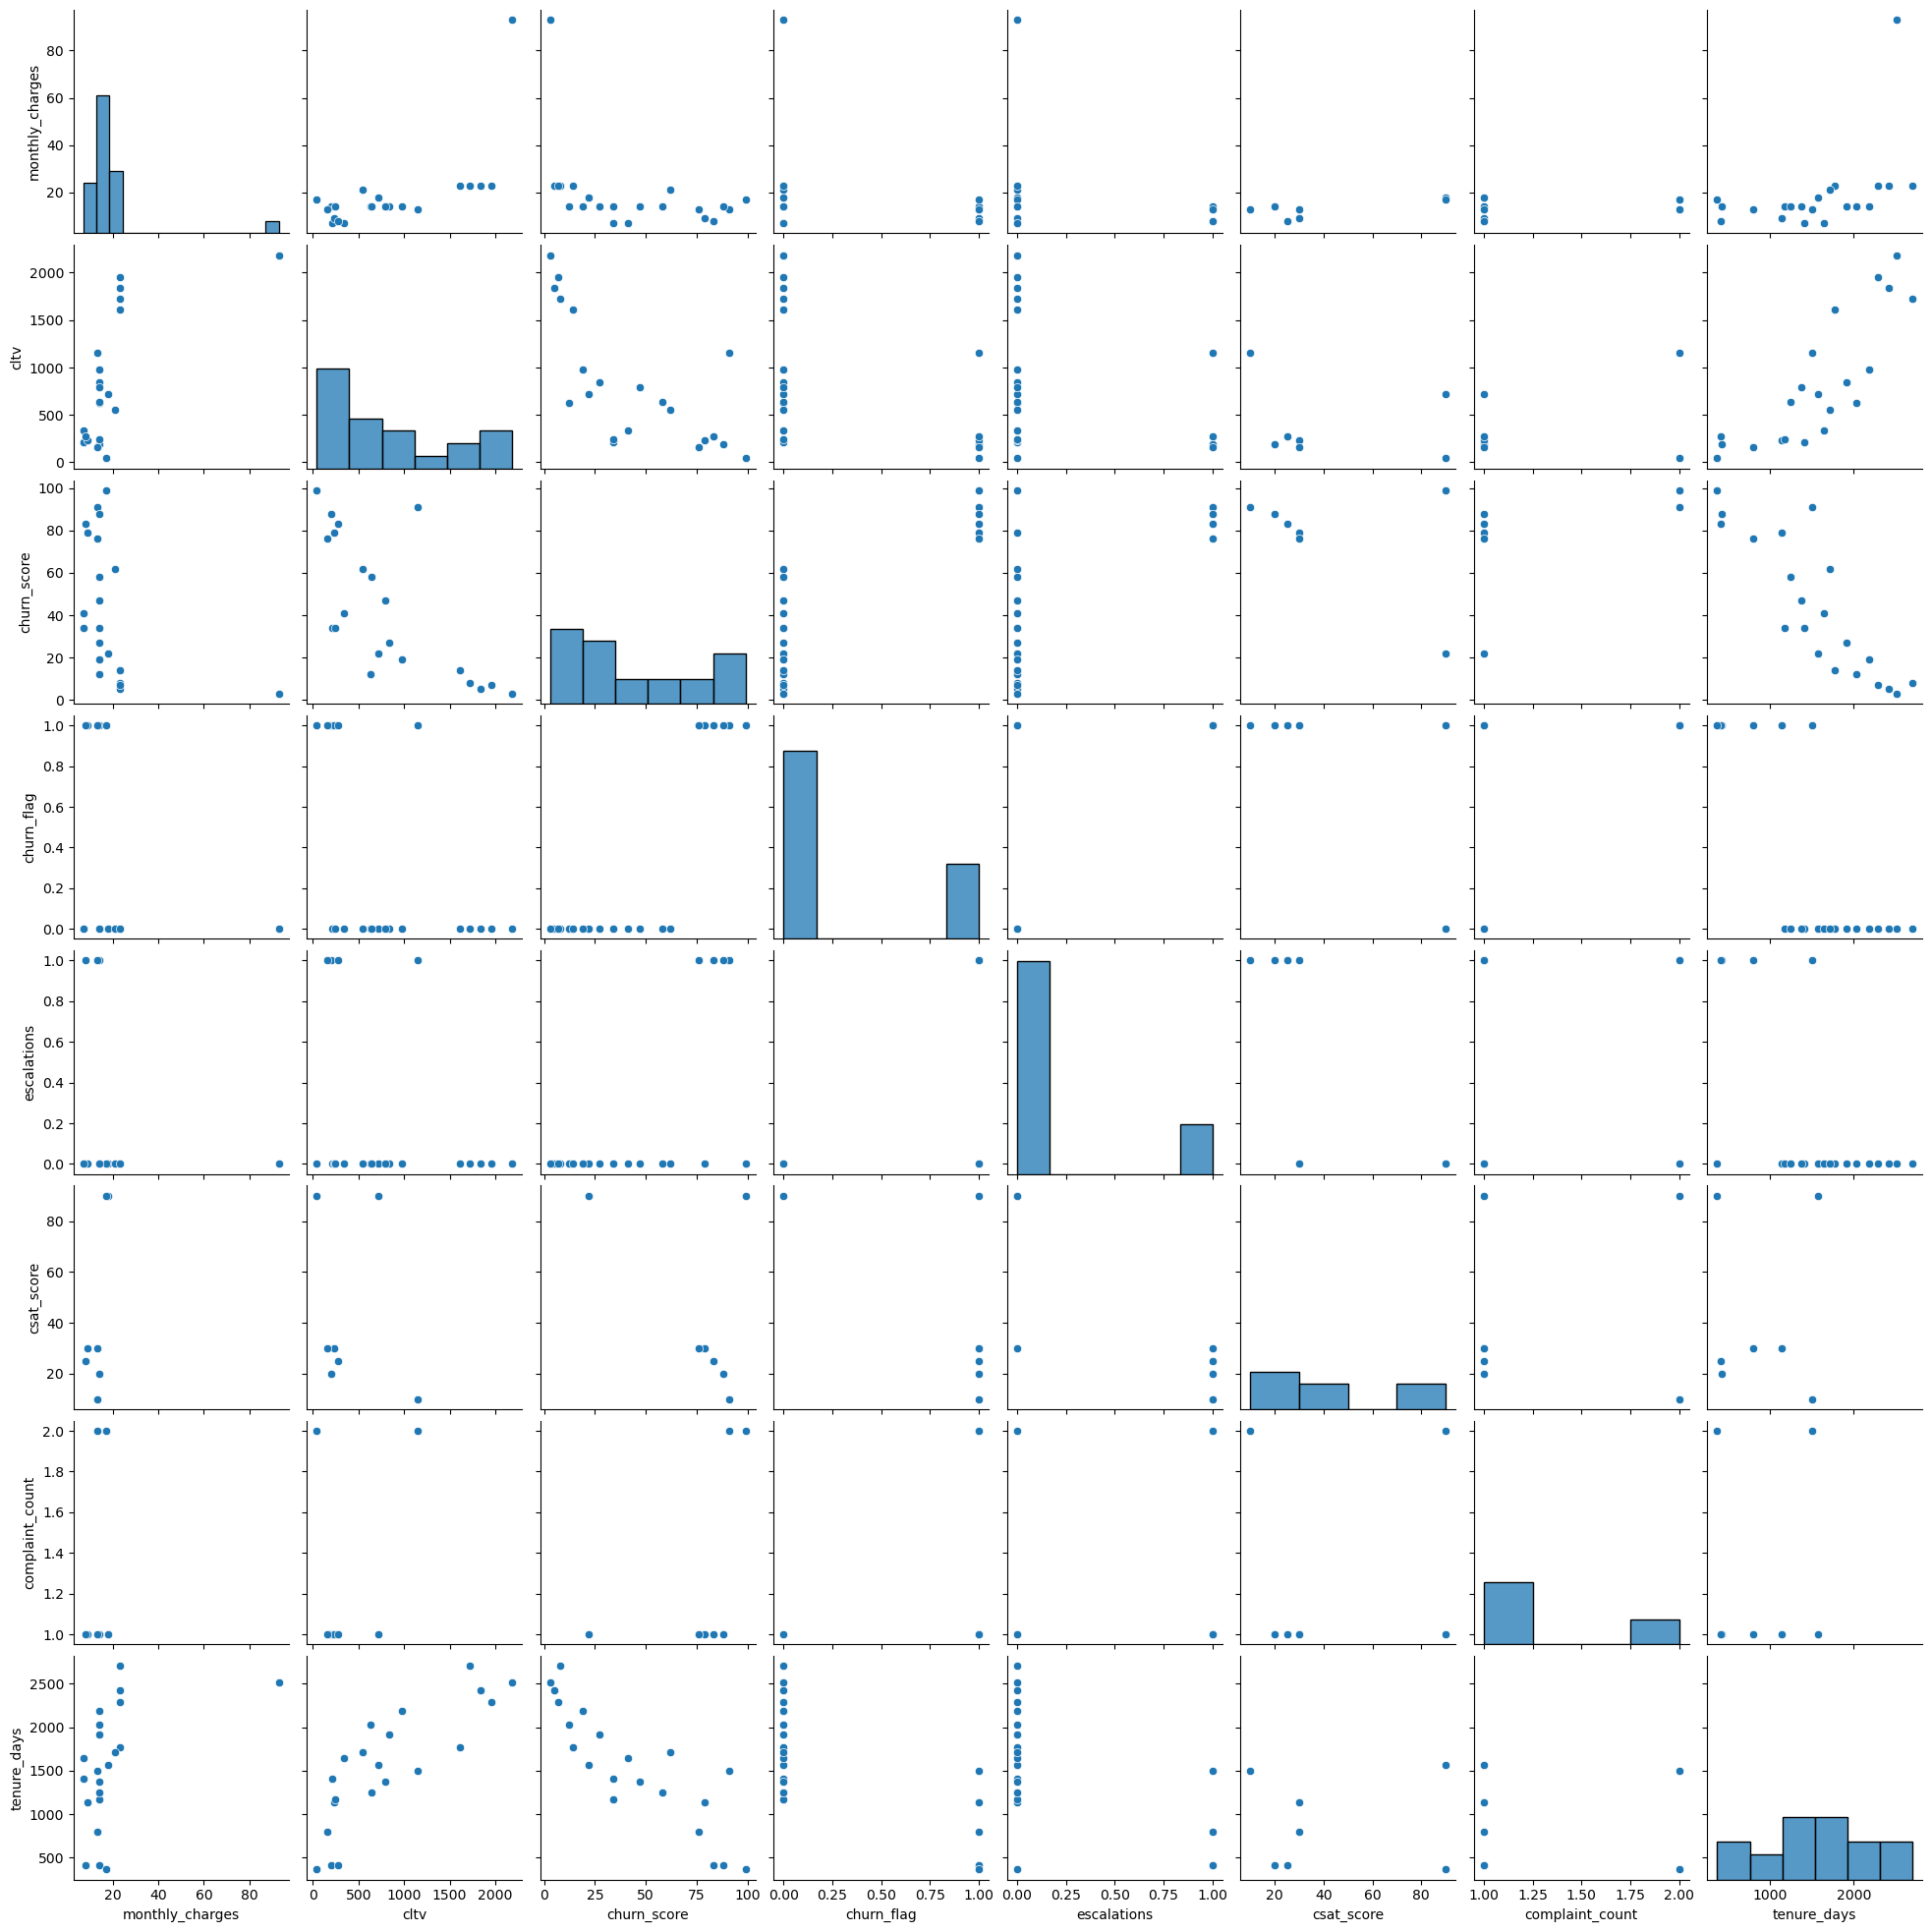

In [189]:
#PairPlot(It shows differenet chart in a single chart and shows their relations as well)
#scatter Plot between different variable in the chart
sns.pairplot(df_visual)

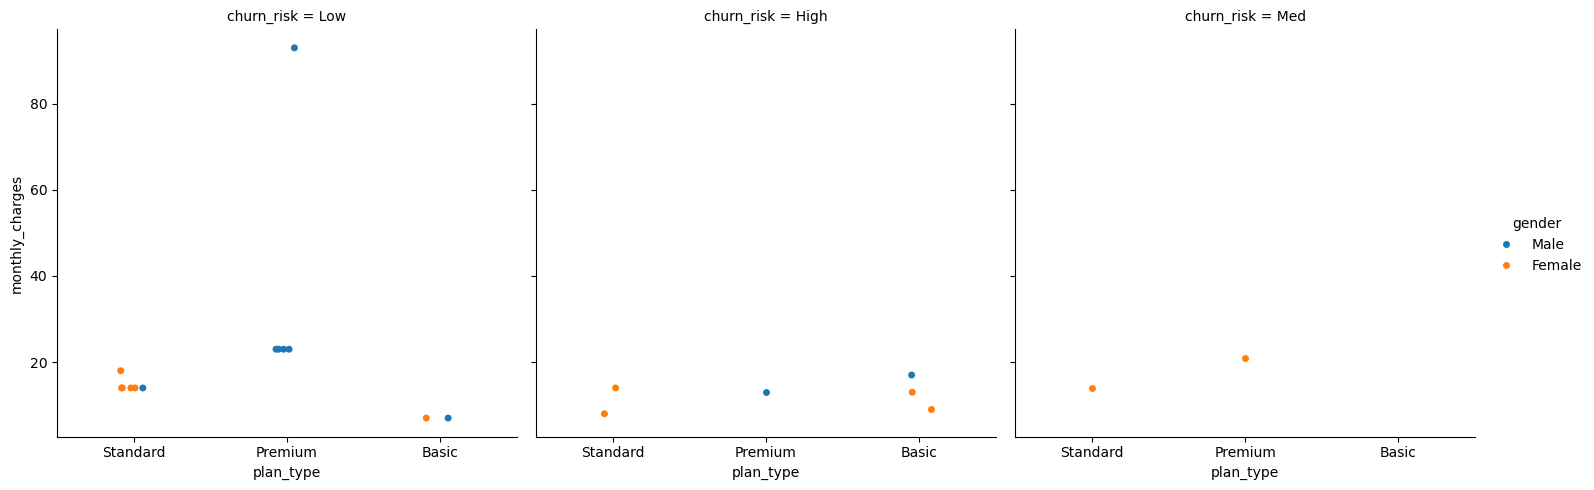

In [190]:
#Categorical plot vs Facegrid Plot 
sns.catplot(data = df_visual,
  x='plan_type',
  y='monthly_charges',
  hue='gender',
  col='churn_risk')

In [191]:
#Pivot table

In [194]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [197]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
        'monthly_charges' : 'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [198]:
#Working with SQL in Python(pandas)

In [199]:
#Create DB in sql
conn=sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

#commit and save
conn.commit()

In [204]:
# Write sql query to insert records in sql table 
cursor = conn.cursor()
cursor.execute(
    """
    INSERT INTO users VALUES
     ('Madhav','india',5000),
     ('Rishab','Germany',5000),
     ('Garvita','india',3500)
    """
    
)

#commit and save
conn.commit()
print("Data Inserted Successfully!")

Data Inserted Successfully!


In [206]:
#Check Inserted Data in table 
conn = sqlite3.connect('test_database.sqlite')
query="""SELECT * FROM users """
df_results = pd.read_sql(query,conn)
df_results.head()

,first_name,country,budget
0,Madhav,india,5000
1,Rishab,Germany,5000
2,Garvita,india,3500


In [209]:
#aggregation 
query = """
  SELECT  country,sum(budget) as total_budget
  FROM users
  GROUP BY country
"""

df_results = pd.read_sql(query,conn)
df_results

,country,total_budget
0,Germany,5000
1,india,8500


In [210]:
#Always close the connection with db once the task is over 
conn.close()